Here we will demonstrate how to generate a stream in the regime of many subhalo impacts.
As usual, a GPU will provide signicant speedup, though this notebook is written for cpu usage.

If you would like to adapt this notebook for product runs on a gpu, change all usages of ``gen_stream_scan_with_pert`` to ``gen_stream_vmapped_with_pert``. The latter is optimized for gpu performancem, the former for cpu performance. This is due to difference between ``jax.lax.scan`` and ``jax.vmap``.

In [1]:
from gala.units import UnitSystem
from astropy import units as u
usys = UnitSystem(u.kpc, u.Myr, u.Msun, u.radian)
import jax.numpy as jnp
from astropy.coordinates import SkyCoord, Galactocentric
from copy import copy 

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

from streamsculptor import potential
from streamsculptor.potential import (nfw_params_from_infall, make_tnfw_potential_from_density_profile, 
                                     make_tnfw_potential_from_infall, tidally_evolved_nfw_params_from_infall, 
                                        HernquistPotential, tnfw_enclosed_mass, get_potential_from_density)
from streamsculptor import JaxCoords as jc
import diffrax


from streamsculptor import JaxCoords as jc

import matplotlib as mpl

## Some plotting things (not necessary)
import scienceplots
plt.style.use('science')
mpl.rcParams['text.usetex'] = False ## We do not have LaTex on the HPC...

First we will define a gd-1 centric frame. These transformations are written in Jax so they can be differentiated.

In [2]:
@jax.jit
def icrs_to_gd1(ra_rad, dec_rad):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> gd1 phi1, phi2
    Using the rotation matrix from Koposov+2010
    ra_rad: icrs ra [radians]
    dec_red: icrs dec [radians]
    """
    R = jnp.array(
        [
            [-0.4776303088, -0.1738432154, 0.8611897727],
            [0.510844589, -0.8524449229, 0.111245042],
            [0.7147776536, 0.4930681392, 0.4959603976],
        ]
    )


    icrs_vec = jnp.vstack([jnp.cos(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(dec_rad)]).T

    stream_frame_vec = jnp.einsum('ij,kj->ki',R,icrs_vec)
    
    phi1 = jnp.arctan2(stream_frame_vec[:,1],stream_frame_vec[:,0])*180/jnp.pi
    phi2 = jnp.arcsin(stream_frame_vec[:,2])*180/jnp.pi

    
    return phi1, phi2

@jax.jit
def get_phi12_from_stream(stream):
    """
    Differentiable helper function that takes us from simulated stream --> phi1, phi2
    """
    ra_s, dec_s, dist_ = jax.vmap(jc.simcart_to_icrs)(stream[:,:3])
    phi1_model, phi2_model = icrs_to_gd1(ra_s*jnp.pi/180, dec_s*jnp.pi/180)
    return phi1_model, phi2_model


Estimated progenitor location today in [kpc, kpc, kpc, kpc/Myr, kpc/Myr, kpc/Myr]
Estimated in a seperate file, but will provide a good starting point for this notebook. This file can be found in the data folder of the streamsculptor repository:
``data/GD1_prog/GD1_progenitor.npy``

In [3]:
prog_wtoday = jnp.load('../data/GD1_prog/GD1_progenitor.npy',allow_pickle=True).item()
pos = prog_wtoday.pos.xyz.to(u.kpc).value
vel = prog_wtoday.vel.d_xyz.to(u.kpc/u.Myr).value
prog_wtoday = jnp.hstack([pos,vel])


Setup the potential, stream age, dissolution time, stripping times. Then generate an unperturbed stream:

In [4]:
## Use Gala's MW potential
pot = potential.GalaMilkyWayPotential(units=usys)
## Define the age of the stream [Myr]
t_age = 2500.0
## Past time at which it dissolved [Myr]
t_dissolve = -300.0
## Get initial conditions
IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age])).ys[0]
## Define stripping times. ts[-1] is always the final integration time for gen_stream simulations
ts = jnp.hstack([jnp.linspace(-t_age,t_dissolve,2_000), jnp.array([0.0])])
## Generate unperturbed stream [l: lead, t: trail]
l ,t = pot.gen_stream_scan(prog_w0=IC,ts=ts,seed_num=532,Msat=1e4,atol=1e-6,rtol=1e-6,solver=diffrax.Dopri5())
stream = jnp.vstack([l,t])

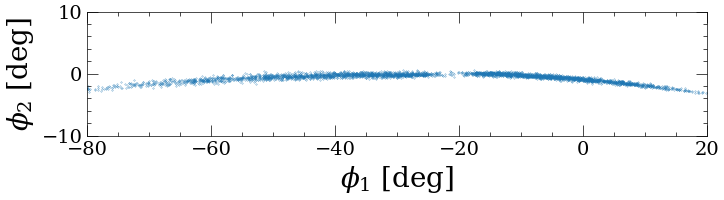

In [5]:
phi1_model, phi2_model = get_phi12_from_stream(stream)

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(phi1_model, phi2_model,s=.05,color='tab:blue')

    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-80,20)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

Goodbye, stream. 

Now we will introduce $N$ subhalos, using the ```ImpactGenerator```. The docstring of this function provides a decent overview, but the basic idea is that we randomly generate impacts by taking the average phase-space location of particles in $\phi_1$ bands (one such average gives us a "phase-space patch"), integrate back to an impact time, and randomly sample impact parameters, angles, and speeds in the frame of the phase-space patch we have just backwards integrated. 

We record the randomly sampled impact parameters, and a Cartesian representation of the subhalo fly-by, and output this information for use in setting up the potentials of the fly-bys. The bounds of the impact parameters (including time of impact, impact angles, distance of closest approach, etc.) can all be adjusted. Sensible defaults are provided.

Here's an example usage with 20 subhalos. Notice that for any case, the ``ImpactGenerator`` needs the unperturbed stream's $\phi_1$ coordinate to parametrize the impacts. This coordinate can be in physical units of (e.g.) length, deg, radian, etc. The only requirement is that it is some scalar parameter that is mappable to the arclength of the stream's track. 

In [6]:
from streamsculptor.GenerateImpactParams import ImpactGenerator

number_of_halos = 100
ImpactGen = ImpactGenerator(pot=pot, 
                            tobs=0.0, 
                            stream=stream, 
                            stream_phi1=phi1_model, 
                            phi1_bounds=[-80.,20.],
                            tImpactBounds=[-2500,0.0],
                            phi1window=.8, 
                            NumImpacts=number_of_halos,
                            bImpact_bounds=[0,.1],
                            stripping_times=jnp.hstack([ts[:-1],ts[:-1]]),
                            prog_today=prog_wtoday,
                            seednum=10)#10

ImpactDict = ImpactGen.get_subhalo_ImpactParams()
print(ImpactDict.keys())

dict_keys(['CartesianImpactParams', 'ImpactFrameParams'])


Impact times are sampled from a pdf that is proportional to the stream's estimated length over time

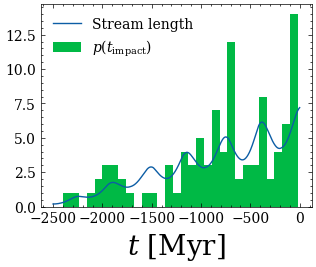

In [7]:
tImp = ImpactDict['ImpactFrameParams']['tImpact']
length_osc = ImpactGen.length_osc
plt.plot(length_osc['ts'],length_osc['length_func']/3,label='Stream length')
plt.hist(tImp,bins=30, label=r'$p(t_{\rm impact})$');
plt.xlabel(r'$t$ [Myr]',fontsize=20)

plt.legend()


In [8]:
ImpactDict['CartesianImpactParams'].sum()

Array(420.25274866, dtype=float64)

In [9]:
ImpactDict['ImpactFrameParams'].keys()

dict_keys(['bImpact', 'perp_angle', 'phi1_samples', 'tImpact'])

In [10]:
# Impact parameters (b)
ImpactDict['ImpactFrameParams']['bImpact']

Array([0.00485476, 0.05207129, 0.00502186, 0.05399589, 0.03015059,
       0.02254782, 0.09186967, 0.0167615 , 0.09841352, 0.05774199,
       0.07946987, 0.00048576, 0.07767951, 0.00047578, 0.03747469,
       0.06012807, 0.02436086, 0.06561836, 0.00115157, 0.02306978,
       0.0123963 , 0.0111845 , 0.06538992, 0.0551338 , 0.06792625,
       0.09163317, 0.09691218, 0.06789009, 0.09957961, 0.05958072,
       0.00489705, 0.09701966, 0.07468234, 0.00638241, 0.05903804,
       0.01836928, 0.09025377, 0.07681439, 0.08222032, 0.05436846,
       0.00460256, 0.01582759, 0.06390775, 0.03361051, 0.07085   ,
       0.06811391, 0.05656581, 0.08211591, 0.07174852, 0.09503767,
       0.06539953, 0.03441873, 0.03394225, 0.05824429, 0.07645607,
       0.03572334, 0.0231253 , 0.06720252, 0.00693487, 0.02459843,
       0.08399759, 0.0881745 , 0.02548251, 0.06980013, 0.00340988,
       0.00110469, 0.07690458, 0.00698574, 0.01319986, 0.08120392,
       0.08496023, 0.01590377, 0.07017591, 0.09768814, 0.04553

Now we will set up a function to generate the perturbed stream, given a 1d array of masses and scale-radii for the subhalos (length of these arrays == number of subhalos). We will jit compile the function. For production runs, this entire notebook can, in principle, be jit compiled. 

We will use the function ``gen_stream_vmapped_with_pert`` to generate the stream with perturbations.

In [11]:
from streamsculptor import gen_stream_vmapped_with_pert

In [12]:
@jax.jit
def gen_perturbed_stream_TNFW(m_infall, c_infall, z_infall, f_bound, ImpactDict):
    
    pot_SH = potential.TNFWSubhaloLinePotential(m_infall, 
                                               c_infall, 
                                               z_infall, 
                                               f_bound, 
                                               subhalo_x0=ImpactDict['CartesianImpactParams'][0:index_max,:3],
                                            subhalo_v=ImpactDict['CartesianImpactParams'][0:index_max,3:],
                                            subhalo_t0=ImpactDict['ImpactFrameParams']['tImpact'][0:index_max], 
                                               t_window=jnp.array([150.0]),
                                            units=usys)
    pot_lst = [pot, pot_SH]
    pot_total = potential.Potential_Combine(pot_lst,units=usys)

    IC = pot_total.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age]),max_steps=10_000).ys[0]
    l ,t = gen_stream_vmapped_with_pert(pot_base=pot, pot_pert=pot_SH, prog_w0=IC, ts=ts, seed_num=532, Msat=1e4, max_steps=5_000,
                                        atol=1e-6,rtol=1e-6, solver=diffrax.Dopri5(), dtmin=.05)
    stream = jnp.vstack([l,t])
    return stream

def gen_perturbed_stream(m, rs, ImpactDict):

    pot_SH = potential.SubhaloLinePotential(m=m, 
                                            a=rs,
                                            subhalo_x0=ImpactDict['CartesianImpactParams'][0:index_max,:3],
                                            subhalo_v=ImpactDict['CartesianImpactParams'][0:index_max,3:],
                                            subhalo_t0=ImpactDict['ImpactFrameParams']['tImpact'][0:index_max], 
                                            t_window=jnp.array([150.0]),
                                            units=usys)

    pot_lst = [pot, pot_SH]
    pot_total = potential.Potential_Combine(pot_lst,units=usys)

    IC = pot_total.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age]),max_steps=10_000).ys[0]
    l ,t = gen_stream_vmapped_with_pert(pot_base=pot, pot_pert=pot_SH, prog_w0=IC, ts=ts, seed_num=532, Msat=1e4, max_steps=5_000,
                                        atol=1e-6,rtol=1e-6, solver=diffrax.Dopri5(), dtmin=.05)
    stream = jnp.vstack([l,t])

    return stream

def sample_mass_function(n, slope=1.9, m_low=6.0, m_high=10):
    import numpy as np
    x = np.random.uniform(0, 1, n)
    m = (x * (m_high ** (1 - slope) - m_low ** (1 - slope)) + m_low ** (
                        1 - slope)) ** (
                            (1 - slope) ** -1)
    return 10 ** m

### Examine differences between Hernquist and TNFW profiles with $a = r_s$

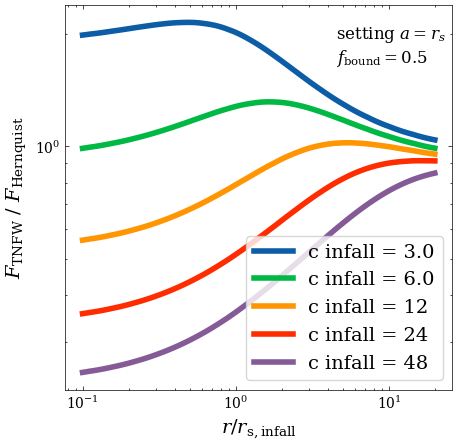

Text(0, 0.5, '$F_{\\rm{TNFW}} \\ / \\ F_{\\rm{Hernquist}}$')

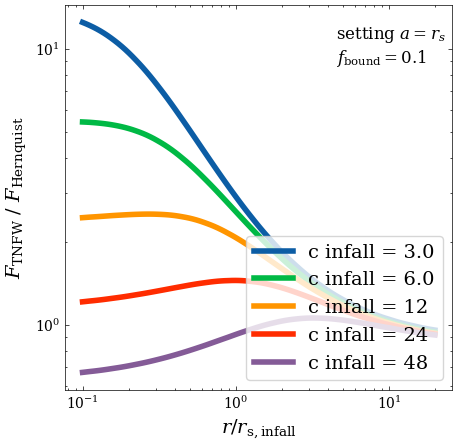

In [13]:
m_infall = 10 ** 8
z_infall = 1.0
f_bound = 0.5

fig = plt.figure(1)
fig.set_size_inches(5,5)
ax= plt.subplot(111)
for c_infall in [3.0, 6.0, 12, 24, 48]:
    rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, 
                                                                c_infall, 
                                                                z_infall,
                                                               f_bound)
    pot_tnfw = make_tnfw_potential_from_density_profile(rhos, rs, ft, rt, units=usys)
    
    # define the Hernquist profile to have the same total mass within r200 as the TNFW profile
    # rt = r200 for the TNFW profile, we divide by 0.84 so the mass enclosed is the same
    m_hernquist = tnfw_enclosed_mass(c_infall * rs, rhos, rs, ft, rt) / 0.84
    scale_rs_hernquist = 1.
    rs_hernquist = copy(rs) * scale_rs_hernquist
    pot_hernquist = HernquistPotential(m=m_hernquist, r_s=rs_hernquist, units=usys)
    
    r = jnp.logspace(-1, 1.3, 100) * rs
    
    # evaluate gradient along x-axis and take magnitude
    density_tnfw = jnp.array([jnp.linalg.norm(pot_tnfw.density(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    density_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.density(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    
    forces_tnfw = jnp.array([jnp.linalg.norm(pot_tnfw.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    forces_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    
    # plt.loglog(r/rs, density_tnfw, color='k', lw=3, label='TNFW')
    # plt.loglog(r/rs, density_hernquist, color='g', lw=3, label='Hernquist')
    # plt.legend()
    # plt.show()
    plt.loglog(r/rs, forces_tnfw/forces_hernquist, label='c infall = '+str(c_infall), 
              lw=4)

ax.legend(fontsize=14, loc=4, frameon=True)
ax.annotate('setting '+r'$a = r_s$'+'\n'+r'$f_{\rm{bound}}=0.5$', xy=(0.7, 0.85), fontsize=12, xycoords='axes fraction')
ax.set_xlabel(r'$r / r_{\rm{s,infall}}$', fontsize=14)
ax.set_ylabel(r'$F_{\rm{TNFW}} \ / \ F_{\rm{Hernquist}}$', fontsize=14)
plt.show() 

m_infall = 10 ** 8
z_infall = 1.0
f_bound = 0.1

fig = plt.figure(2)
fig.set_size_inches(5,5)
ax= plt.subplot(111)
for c_infall in [3.0, 6.0, 12, 24, 48]:
    rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, 
                                                                c_infall, 
                                                                z_infall,
                                                               f_bound)
    pot_tnfw = make_tnfw_potential_from_density_profile(rhos, rs, ft, rt, units=usys)
    
    # define the Hernquist profile to have the same total mass within r200 as the TNFW profile
    # rt = r200 for the TNFW profile, we divide by 0.84 so the mass enclosed is the same
    m_hernquist = tnfw_enclosed_mass(c_infall * rs, rhos, rs, ft, rt) / 0.84
    scale_rs_hernquist = 1.
    rs_hernquist = copy(rs) * scale_rs_hernquist
    pot_hernquist = HernquistPotential(m=m_hernquist, r_s=rs_hernquist, units=usys)
    
    r = jnp.logspace(-1, 1.3, 100) * rs
    
    # evaluate gradient along x-axis and take magnitude
    density_tnfw = jnp.array([jnp.linalg.norm(pot_tnfw.density(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    density_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.density(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    
    forces_tnfw = jnp.array([jnp.linalg.norm(pot_tnfw.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    forces_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    
    # plt.loglog(r/rs, density_tnfw, color='k', lw=3, label='TNFW')
    # plt.loglog(r/rs, density_hernquist, color='g', lw=3, label='Hernquist')
    # plt.legend()
    # plt.show()
    plt.loglog(r/rs, forces_tnfw/forces_hernquist, label='c infall = '+str(c_infall), 
              lw=4)

ax.legend(fontsize=14, loc=4, frameon=True)
ax.annotate('setting '+r'$a = r_s$'+'\n'+r'$f_{\rm{bound}}=0.1$', xy=(0.7, 0.85), fontsize=12, xycoords='axes fraction')
ax.set_xlabel(r'$r / r_{\rm{s,infall}}$', fontsize=14)
ax.set_ylabel(r'$F_{\rm{TNFW}} \ / \ F_{\rm{Hernquist}}$', fontsize=14)


Run the simulation:

Here we load a tidal evolution model developed for the Milky Way from pyHalo. The code makes the same assumptions as the analysis recently done for strong lensing. It predicts the bound mass fraction from the infall time and concentration, and gets the dnesity profile from the tidal tracks

In [14]:
from pyHalo.Halos.accretion import InfallDistributionDirectMilkyWay30kpc
from pyHalo.Halos.concentration import ConcentrationDiemerJoyce
from pyHalo.Halos.galacticus_truncation.interp_mass_loss import InterpGalacticusMW
from astropy.cosmology import Planck18
from colossus.cosmology import cosmology
from scipy.interpolate import interp1d

cosmology.setCosmology('planck18')

tidal_evolution_model = InterpGalacticusMW(rmax=30) # we load the model calibrated for r < 30 kpc in the MW
z_eval = 0.0
logM_MW = 12.0
chost = 9.0
infall_redshift_sampling = InfallDistributionDirectMilkyWay30kpc(z_eval, logM_MW)
concentration_mass_relation = ConcentrationDiemerJoyce(Planck18)
zvalues_interp = jnp.linspace(0.0, 10, 100)
t = [Planck18.lookback_time(zi).value for zi in zvalues_interp]
time_since_infall_interp = interp1d(zvalues_interp, t)

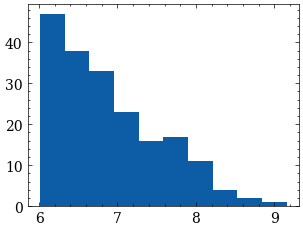

number of infalling perturbers:  1000
number of surviving perturbers:  192


In [15]:
number_of_halos = 1000
_m_infall = sample_mass_function(number_of_halos)

m_infall = []
c_infall = []
z_infall = []
f_bound = []

bound_mass_cut = 10 ** 6
for m in _m_infall:
    z = infall_redshift_sampling(m)
    c = concentration_mass_relation.nfw_concentration(m, z)
    t_since_infall = time_since_infall_interp(z)
    log10_fbound = tidal_evolution_model(jnp.log10(c), t_since_infall, chost)

    if m * 10**log10_fbound >= bound_mass_cut:
        m_infall.append(m)
        c_infall.append(c)
        z_infall.append(z)
        f_bound.append(10 ** log10_fbound)

m_infall = jnp.array(m_infall)
c_infall = jnp.array(c_infall)
z_infall = jnp.array(z_infall)
f_bound = jnp.array(f_bound)
index_max = len(c_infall)
plt.hist(jnp.log10(f_bound * m_infall)); plt.show()

num_surviving_subhalos = len(m_infall)
print('number of infalling perturbers: ', number_of_halos)
print('number of surviving perturbers: ', num_surviving_subhalos)
ImpactGen = ImpactGenerator(pot=pot, 
                        tobs=0.0, 
                        stream=stream, 
                        stream_phi1=phi1_model, 
                        phi1_bounds=[-80.,20.],
                        tImpactBounds=[-2500,0.0],
                        phi1window=.8, 
                        NumImpacts=num_surviving_subhalos,
                        bImpact_bounds=[0,.1],
                        stripping_times=jnp.hstack([ts[:-1],ts[:-1]]),
                        prog_today=prog_wtoday,
                        seednum=10)#10
ImpactDict = ImpactGen.get_subhalo_ImpactParams()

perturbed_stream_tnfw = gen_perturbed_stream_TNFW(m_infall, c_infall, z_infall, f_bound, ImpactDict)

# _, rs_infall, _ = nfw_params_from_infall(m_infall, c_infall, z_infall)
#rs_hernquist = copy(rs_infall) # the same scale radius as each TNFW halo
m_hernquist = f_bound * m_infall # the same mass as each TNFW halo
rs_hernquist = 1.05 * jnp.sqrt(m_hernquist / 10 ** 8)
perturbed_stream_hernquist = gen_perturbed_stream(m_hernquist, rs_hernquist, ImpactDict)


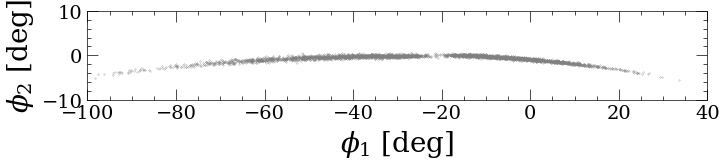

In [16]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)

ax.scatter(phi1_model, phi2_model,s=.05,color='grey')
    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-100,40)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

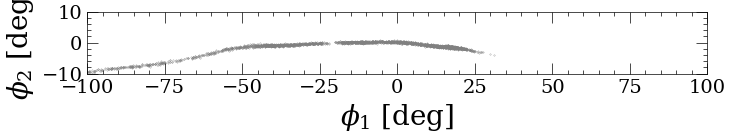

In [17]:
phi1_pert, phi2_pert = get_phi12_from_stream(perturbed_stream_hernquist[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)


ax.scatter(phi1_pert, phi2_pert,s=.05,color='grey')

    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-100,100)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

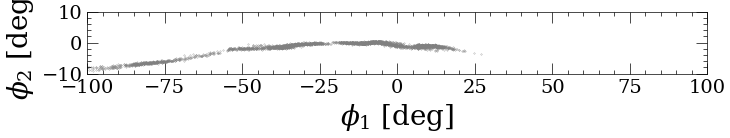

In [18]:
phi1_pert_tnfw, phi2_pert_tnfw = get_phi12_from_stream(perturbed_stream_tnfw[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)


ax.scatter(phi1_pert_tnfw, phi2_pert_tnfw,s=.05,color='grey')

    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-100,100)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

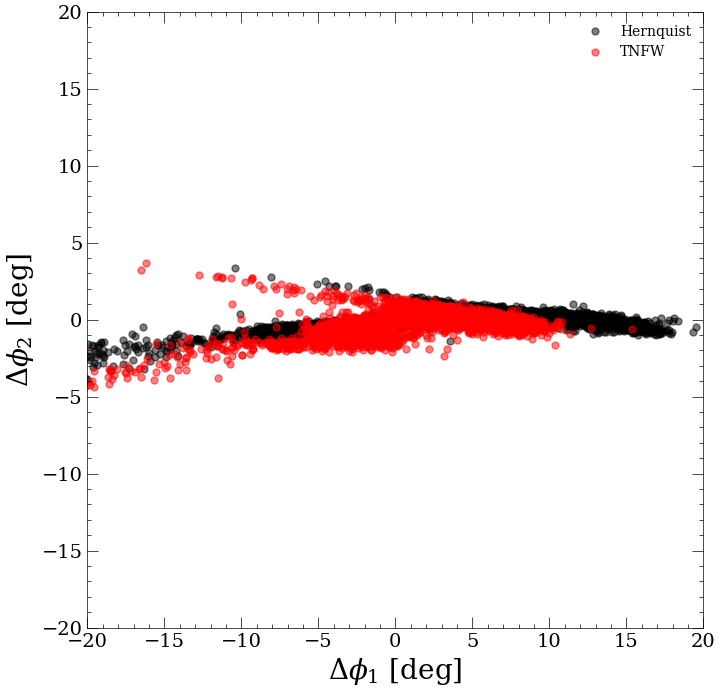

In [19]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)

#ax.scatter(phi1_model, phi2_model,s=.05,color='grey')
ax.scatter(phi1_pert-phi1_model, phi2_pert-phi2_model,s=25,color='k',alpha=0.5, label='Hernquist')
ax.scatter(phi1_pert_tnfw-phi1_model, phi2_pert_tnfw-phi2_model,s=25,color='r',alpha=0.5, label='TNFW')

ax.legend()
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-20,20)
ax.set_xlim(-20,20)
ax.set_xlabel(r'$\Delta \phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\Delta \phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [62]:
def volume_avg_force_hernquist(b, m, rs, n_points=50):
    pot_h = HernquistPotential(m=m, r_s=rs, units=usys)
    grad_h = jax.grad(lambda xyz: pot_h.potential(xyz, 0.0).sum())
    r_vals = jnp.linspace(0.01 * b, b, n_points)
    forces = jax.vmap(lambda r: jnp.linalg.norm(grad_h(jnp.array([r, 0.0, 0.0]))))(r_vals)
    integrand = forces * r_vals**2
    avg_force = (3.0 / b**3) * jnp.trapezoid(integrand, r_vals)
    return avg_force

def volume_avg_force_tnfw(b, m_infall, c_infall, z_infall, f_bound, n_points=50):
    pot_t = make_tnfw_potential_from_infall(m_infall, c_infall, z_infall, f_bound, units=usys)
    grad_t = jax.grad(lambda xyz: pot_t.potential(xyz, 0.0).sum())
    r_vals = jnp.linspace(0.01 * b, b, n_points)
    forces = jax.vmap(lambda r: jnp.linalg.norm(grad_t(jnp.array([r, 0.0, 0.0]))))(r_vals)
    integrand = forces * r_vals**2
    avg_force = (3.0 / b**3) * jnp.trapezoid(integrand, r_vals)
    return avg_force

avg_forces_tnfw = jnp.array([
    volume_avg_force_tnfw(bImpact[i], m_infall[i], c_infall[i], z_infall[i], f_bound[i])
    for i in range(num_surviving_subhalos)
])

avg_forces_hernquist = jnp.array([
    volume_avg_force_hernquist(bImpact[i], m_hernquist[i], rs_hernquist[i])
    for i in range(num_surviving_subhalos)
])


### Volume averaged forces 

Here we compute the mean force exerted by each perturber inside the impact parameter $b$. This takes a long time for some reason

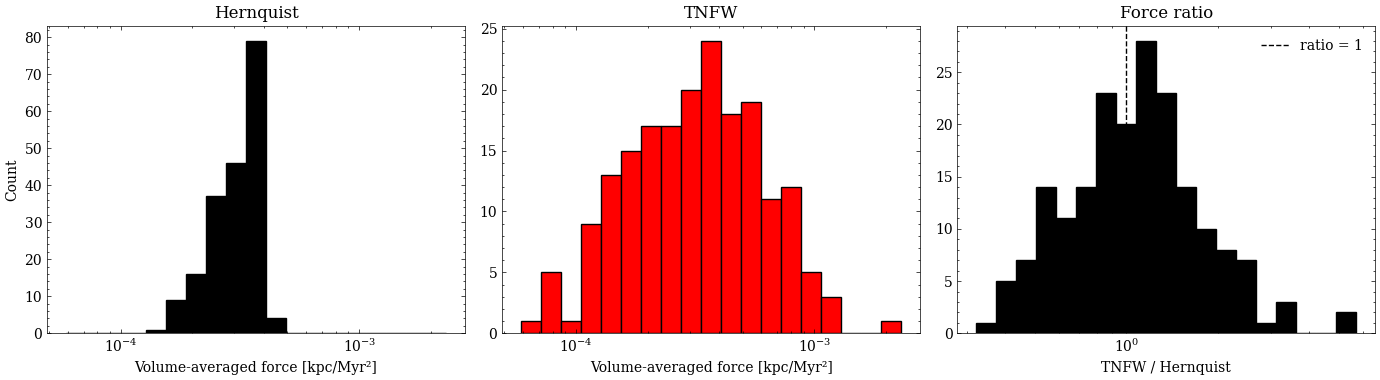

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_forces = jnp.concatenate([avg_forces_hernquist, avg_forces_tnfw])
bins = jnp.logspace(jnp.log10(all_forces.min()), jnp.log10(all_forces.max()), 20)

axes[0].hist(avg_forces_hernquist, bins=bins, color='k', edgecolor='k')
axes[0].set_xscale('log')
axes[0].set_xlabel('Volume-averaged force [kpc/Myr²]')
axes[0].set_ylabel('Count')
axes[0].set_title('Hernquist')

axes[1].hist(avg_forces_tnfw, bins=bins, color='r', edgecolor='k')
axes[1].set_xscale('log')
axes[1].set_xlabel('Volume-averaged force [kpc/Myr²]')
axes[1].set_title('TNFW')

ratio = avg_forces_tnfw / avg_forces_hernquist
ratio_bins = jnp.logspace(jnp.log10(ratio.min()), jnp.log10(ratio.max()), 20)
axes[2].hist(ratio, bins=ratio_bins, color='k', edgecolor='k')
axes[2].set_xscale('log')
axes[2].set_xlabel('TNFW / Hernquist')
axes[2].set_title('Force ratio')
axes[2].axvline(1.0, color='k', linestyle='--', label='ratio = 1')
axes[2].legend()

plt.tight_layout()
plt.show()

### Central density 
Here we compare the central density of each population of subhalos

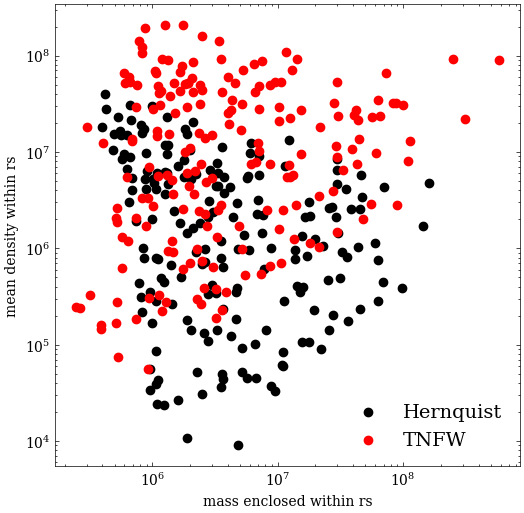

In [68]:
def rho_tnfw(r, rhos, rs, ft, rt):
    x = r/rs
    return rhos / (x * (1+x)**2) / (1+r**2/rt**2)

def tnfw_mean_density_mass_inside_rs(rhos, rs, ft, rt):
    
    tau = rt/rs
    prefactor = 3 * rhos * tau**2 / (1 + tau**2)
    term = jnp.log(2) + 0.5 - 0.5 * jnp.log(1 + tau**2) + jnp.arctan(1 / tau) / tau
    mean_density_inside_rs = ft * prefactor * term
    _r = jnp.logspace(-3, 0.0, 100)
    mass_inside_rs = []
    for i in range(0, len(rhos)):
        r = _r * rs[i]
        m = jnp.trapezoid(4*jnp.pi*rho_tnfw(r, rhos[i], rs[i], ft[i], rt[i])*r**2, r)
        mass_inside_rs.append(m)
        
    return mean_density_inside_rs, jnp.array(mass_inside_rs)
    
def hernquist_mean_density_mass_inside_a(m_total, a, r_match):
    """
    we compute mean density and mass inside r_match
    """
    rho = m_total / (2*jnp.pi*a**3)
    x = r_match / a
    rho_mean = 1.5 * rho / x / (1+x)** 2
    m_enclosed = m_total * x**2 / (1+x)**2
    return rho_mean, m_enclosed

rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, 
                                                                c_infall, 
                                                                z_infall,
                                                               f_bound)

rho_mean_tnfw, m_tnfw = tnfw_mean_density_mass_inside_rs(rhos, rs, ft, rt)
r_match = rs
rho_mean_hernquist, m_hern = hernquist_mean_density_mass_inside_a(m_hernquist, 
                                                                  rs_hernquist,
                                                                 r_match=r_match)

fig = plt.figure()
fig.set_size_inches(6,6)
ax = plt.subplot(111)

ax.scatter(m_hern, rho_mean_hernquist, color='k', label='Hernquist')
ax.scatter(m_tnfw, rho_mean_tnfw, color='r', label='TNFW')
ax.legend(fontsize=14)
ax.set_xlabel('mass enclosed within rs')
ax.set_ylabel('mean density within rs')
ax.set_xscale('log')
ax.set_yscale('log')
